In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/amdatas/fruits-diseases-classification-dataset/FRUITS DISEASES CLASSIFICATION/POMEGRANATE/Anthracnose_Pomegranate/IMG_20230813_151636.jpg
/kaggle/input/datasets/amdatas/fruits-diseases-classification-dataset/FRUITS DISEASES CLASSIFICATION/POMEGRANATE/Anthracnose_Pomegranate/IMG_20230903_131050.jpg
/kaggle/input/datasets/amdatas/fruits-diseases-classification-dataset/FRUITS DISEASES CLASSIFICATION/POMEGRANATE/Anthracnose_Pomegranate/IMG_20230903_130703_1.jpg
/kaggle/input/datasets/amdatas/fruits-diseases-classification-dataset/FRUITS DISEASES CLASSIFICATION/POMEGRANATE/Anthracnose_Pomegranate/IMG_20230903_142451.jpg
/kaggle/input/datasets/amdatas/fruits-diseases-classification-dataset/FRUITS DISEASES CLASSIFICATION/POMEGRANATE/Anthracnose_Pomegranate/IMG_20230903_150143.jpg
/kaggle/input/datasets/amdatas/fruits-diseases-classification-dataset/FRUITS DISEASES CLASSIFICATION/POMEGRANATE/Anthracnose_Pomegranate/IMG_20230903_135105.jpg
/kaggle/input/datasets/amdatas/f

In [2]:
import numpy as np
import os
import shutil
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

2026-04-12 05:55:32.393171: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775973332.588613      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775973332.640282      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775973333.071311      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775973333.071352      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775973333.071355      23 computation_placer.cc:177] computation placer alr

In [3]:
original_path = '/kaggle/input/datasets/amdatas/fruits-diseases-classification-dataset/FRUITS DISEASES CLASSIFICATION'
new_path = '/kaggle/working/processed_dataset'
os.makedirs(new_path, exist_ok=True)

for fruit in os.listdir(original_path):
    fruit_path = os.path.join(original_path, fruit)
    if os.path.isdir(fruit_path):
        for disease in os.listdir(fruit_path):
            disease_path = os.path.join(fruit_path, disease)
            if os.path.isdir(disease_path):
                new_class_name = f"{fruit}_{disease}"
                new_class_path = os.path.join(new_path, new_class_name)
                os.makedirs(new_class_path, exist_ok=True)
                for img in os.listdir(disease_path):
                    shutil.copy(
                        os.path.join(disease_path, img),
                        os.path.join(new_class_path, img)
                    )
print("Dataset restructured!")

Dataset restructured!


In [4]:
class_counts = {}
for class_name in sorted(os.listdir(new_path)):
    class_dir = os.path.join(new_path, class_name)
    if os.path.isdir(class_dir):
        count = len([f for f in os.listdir(class_dir)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))])
        class_counts[class_name] = count

print("\n Samples per class:")
for cls, cnt in sorted(class_counts.items()):
    print(f"  {cls:<55} {cnt}")


 Samples per class:
  APPLE_Blotch_Apple                                      100
  APPLE_Healthy_Apple                                     100
  APPLE_Rot_Apple                                         100
  APPLE_Scab_Apple                                        100
  GUAVA_Anthracnose_Guava                                 100
  GUAVA_Fruitfly_Guava                                    100
  GUAVA_Healthy_Guava                                     100
  MANGO_Alternaria_Mango                                  115
  MANGO_Anthracnose_Mango                                 79
  MANGO_Black Mould Rot (Aspergillus)_Mango               182
  MANGO_Healthy_Mango                                     205
  MANGO_Stem and Rot (Lasiodiplodia)_Mango                157
  POMEGRANATE_Alternaria_Pomegranate                      886
  POMEGRANATE_Anthracnose_Pomegranate                     1166
  POMEGRANATE_Bacterial_Blight_Pomegranate                966
  POMEGRANATE_Cercospora_Pomegranate             

In [5]:
MIN_SAMPLES = 150 

print(f"\n Oversampling classes below {MIN_SAMPLES} samples...")
for class_name, count in class_counts.items():
    if count < MIN_SAMPLES:
        class_dir = os.path.join(new_path, class_name)
        images = [f for f in os.listdir(class_dir)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
        needed = MIN_SAMPLES - count
        for i in range(needed):
            src = os.path.join(class_dir, images[i % len(images)])
            dst = os.path.join(class_dir, f"oversample_{i}_{images[i % len(images)]}")
            shutil.copy(src, dst)
        print(f" {class_name}: {count} → {MIN_SAMPLES}")


 Oversampling classes below 150 samples...
 APPLE_Blotch_Apple: 100 → 150
 APPLE_Healthy_Apple: 100 → 150
 APPLE_Rot_Apple: 100 → 150
 APPLE_Scab_Apple: 100 → 150
 GUAVA_Anthracnose_Guava: 100 → 150
 GUAVA_Fruitfly_Guava: 100 → 150
 GUAVA_Healthy_Guava: 100 → 150
 MANGO_Alternaria_Mango: 115 → 150
 MANGO_Anthracnose_Mango: 79 → 150


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    new_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    new_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"\n {num_classes} classes loaded")

total_val_batches = val_test_dataset.cardinality().numpy()
val_size = total_val_batches // 2
val_dataset  = val_test_dataset.take(val_size)
test_dataset = val_test_dataset.skip(val_size)

Found 6993 files belonging to 17 classes.
Using 5595 files for training.


I0000 00:00:1775973455.718647      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 6993 files belonging to 17 classes.
Using 1398 files for validation.

 17 classes loaded


In [7]:
all_labels = []
for _, y_batch in train_dataset:
    all_labels.extend(np.argmax(y_batch.numpy(), axis=1))
all_labels = np.array(all_labels)

class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weight_values))

print("\n  Class weights (higher = more important):")
for idx, w in class_weight_dict.items():
    print(f"  [{idx:2d}] {class_names[idx]:<55} {w:.3f}")


  Class weights (higher = more important):
  [ 0] APPLE_Blotch_Apple                                      2.633
  [ 1] APPLE_Healthy_Apple                                     2.633
  [ 2] APPLE_Rot_Apple                                         2.571
  [ 3] APPLE_Scab_Apple                                        2.676
  [ 4] GUAVA_Anthracnose_Guava                                 2.720
  [ 5] GUAVA_Fruitfly_Guava                                    2.813
  [ 6] GUAVA_Healthy_Guava                                     2.743
  [ 7] MANGO_Alternaria_Mango                                  2.720
  [ 8] MANGO_Anthracnose_Mango                                 2.743
  [ 9] MANGO_Black Mould Rot (Aspergillus)_Mango               2.070
  [10] MANGO_Healthy_Mango                                     2.032
  [11] MANGO_Stem and Rot (Lasiodiplodia)_Mango                2.551
  [12] POMEGRANATE_Alternaria_Pomegranate                      0.467
  [13] POMEGRANATE_Anthracnose_Pomegranate                 

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augmentation")

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_dataset  = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [9]:
base_model = EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,844,212 (18.48 MB)

 Trainable params: 3,319,969 (12.66 MB)

 Non-trainable params: 1,524,243 (5.81 MB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_path = '/kaggle/working/best_model.keras'

model_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

In [11]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=model_callbacks,
    class_weight=class_weight_dict  
)

Epoch 1/25


I0000 00:00:1775973527.280517      75 service.cc:152] XLA service 0x79c314001970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775973527.280564      75 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775973533.066002      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-12 05:58:59.186024: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 05:58:59.392174: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 05:58:59.707077: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

174/175 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.2187 - loss: 3.0928

2026-04-12 06:00:28.430910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 06:00:28.639647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 06:00:28.956956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 06:00:29.165345: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.2196 - loss: 3.0886
Epoch 1: val_accuracy improved from -inf to 0.86506, saving model to /kaggle/working/best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 142s 590ms/step - accuracy: 0.2204 - loss: 3.0844 - val_accuracy: 0.8651 - val_loss: 0.7929 - learning_rate: 1.0000e-04
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.6945 - loss: 1.2275
Epoch 2: val_accuracy improved from 0.86506 to 0.92472, saving model to /kaggle/working/best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 88s 496ms/step - accuracy: 0.6947 - loss: 1.2266 - val_accuracy: 0.9247 - val_loss: 0.2775 - learning_rate: 1.0000e-04
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8024 - loss: 0.8712
Epoch 3: val_accuracy improved from 0.92472 to 0.93324, saving model to /kaggle/working/best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 90s 510ms/step - accuracy: 0.8025 - loss: 0.8704 - val_accuracy: 0.9332 - val_loss: 0.2019 - learning_rate: 1

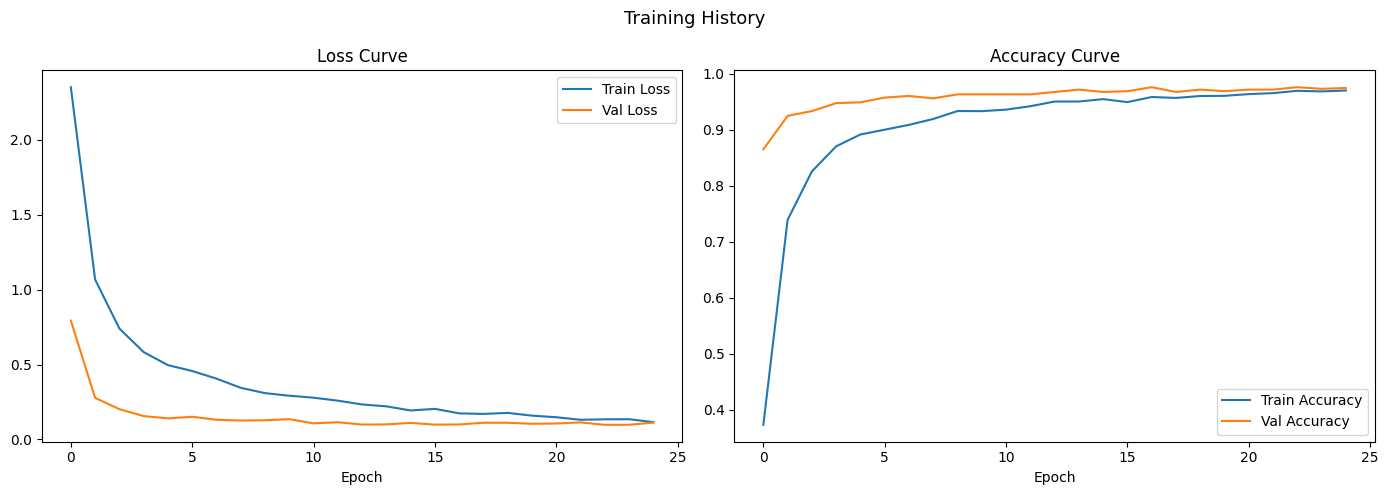

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [13]:
print("\n Loading best checkpoint...")
best_model = tf.keras.models.load_model(checkpoint_path)

loss, accuracy = best_model.evaluate(test_dataset, verbose=1)
print(f"\n Test Loss:     {loss:.4f}")
print(f" Test Accuracy: {accuracy:.4f}")


 Loading best checkpoint...
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 534ms/step - accuracy: 0.9467 - loss: 0.1464

 Test Loss:     0.1175
 Test Accuracy: 0.9597


22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 521ms/step


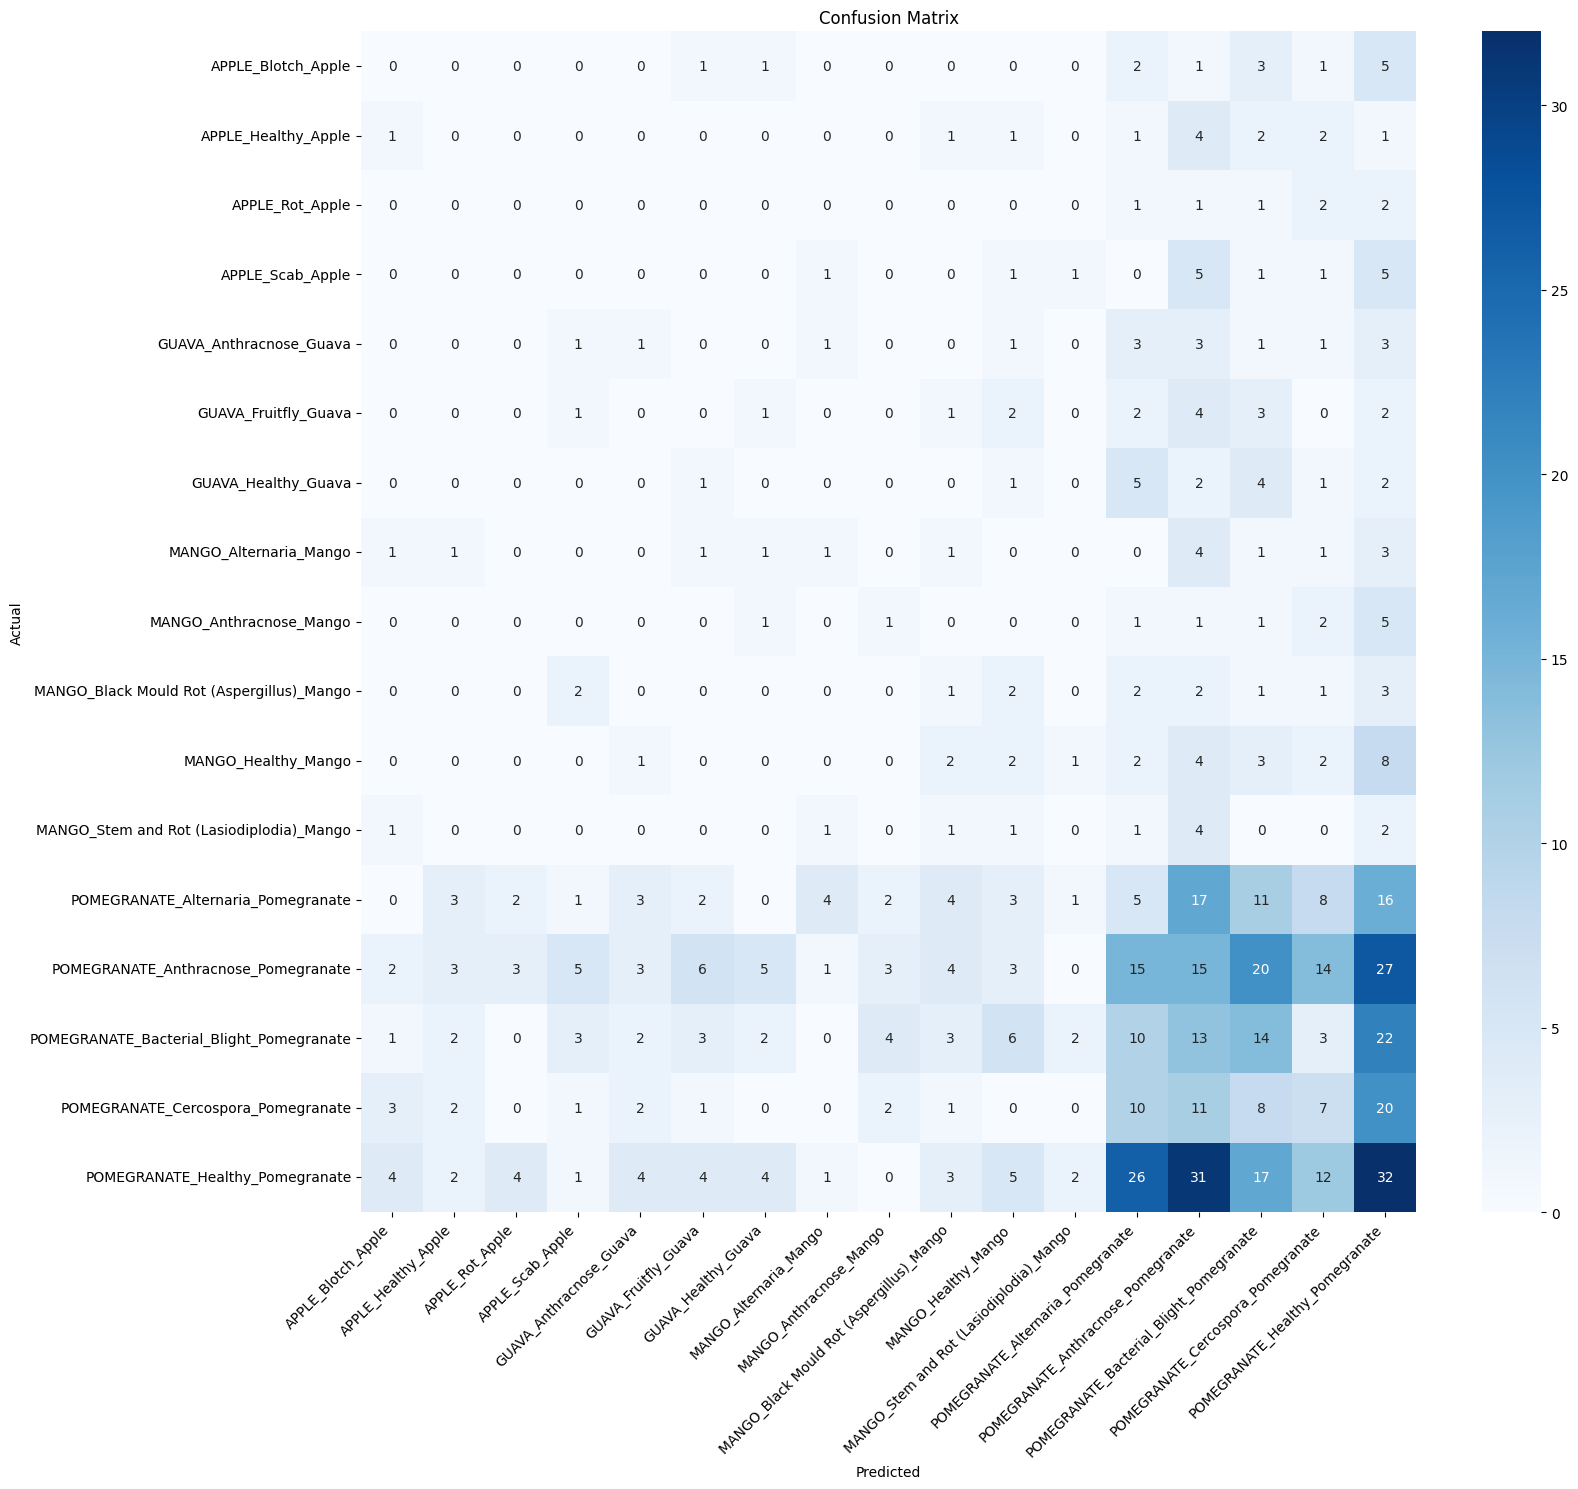

In [14]:
y_true = np.concatenate([y for _, y in test_dataset], axis=0)
y_pred = best_model.predict(test_dataset, verbose=1)

y_true_cls = np.argmax(y_true, axis=1)
y_pred_cls = np.argmax(y_pred,  axis=1)

cm = confusion_matrix(y_true_cls, y_pred_cls)
fig_size = max(14, num_classes)
plt.figure(figsize=(fig_size, fig_size - 2))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

In [15]:
print("\n Classification Report:")
print(classification_report(y_true_cls, y_pred_cls, target_names=class_names))


 Classification Report:
                                           precision    recall  f1-score   support

                       APPLE_Blotch_Apple       0.00      0.00      0.00        14
                      APPLE_Healthy_Apple       0.00      0.00      0.00        13
                          APPLE_Rot_Apple       0.00      0.00      0.00         7
                         APPLE_Scab_Apple       0.00      0.00      0.00        15
                  GUAVA_Anthracnose_Guava       0.06      0.07      0.06        15
                     GUAVA_Fruitfly_Guava       0.00      0.00      0.00        16
                      GUAVA_Healthy_Guava       0.00      0.00      0.00        16
                   MANGO_Alternaria_Mango       0.10      0.07      0.08        15
                  MANGO_Anthracnose_Mango       0.08      0.08      0.08        12
MANGO_Black Mould Rot (Aspergillus)_Mango       0.05      0.07      0.06        14
                      MANGO_Healthy_Mango       0.07      0.0


 Macro ROC-AUC: 0.5229


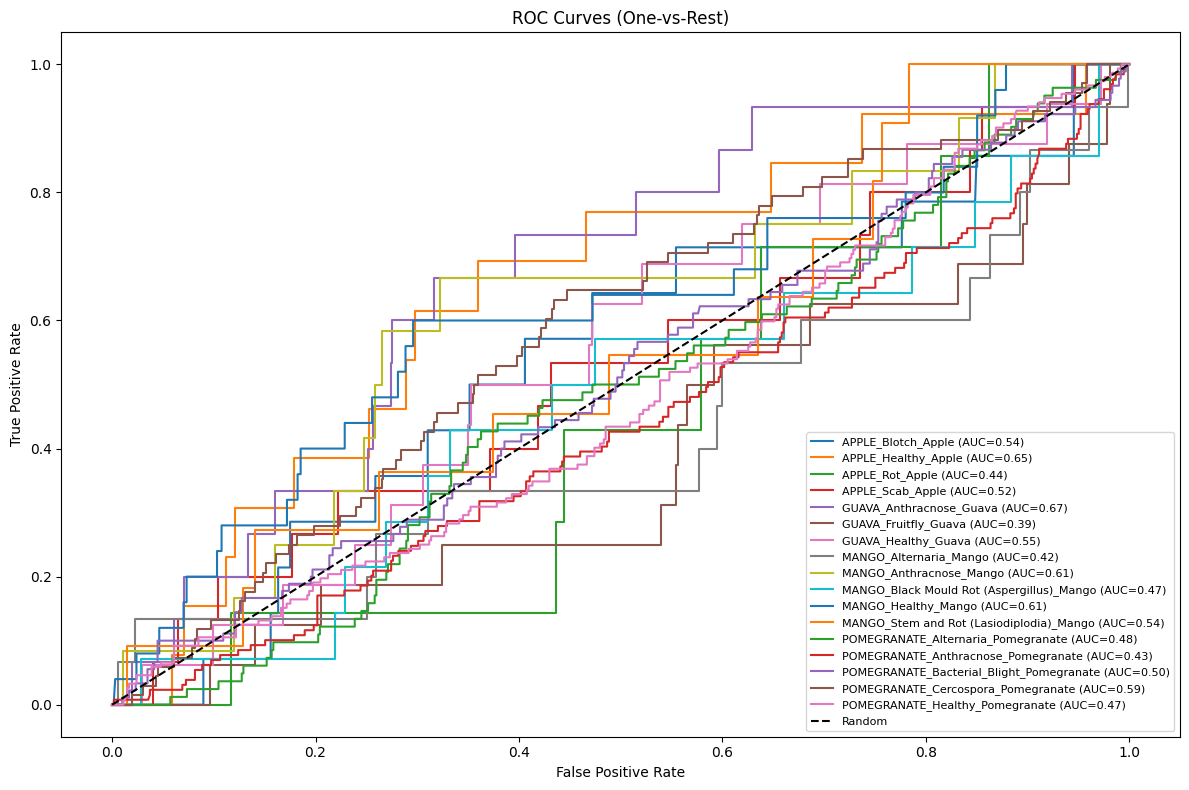

In [16]:
roc_auc = roc_auc_score(y_true, y_pred, multi_class='ovr', average='macro')
print(f"\n Macro ROC-AUC: {roc_auc:.4f}")

plt.figure(figsize=(12, 8))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    auc = roc_auc_score(y_true[:, i], y_pred[:, i])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curves.png', dpi=150)
plt.show()